In [ ]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import pandas as pd
from pymoo.problems import get_problem
from pymoo.indicators.igd import IGD
from pymoo.indicators.hv import HV
from scipy.stats import cauchy
from scipy.spatial.distance import cdist
from tabulate import tabulate
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import cauchy, qmc
from typing import List, Optional, Any

In [ ]:


class ProblemWrapper:
    def __init__(self, p_prob: Any):
        self.n_var = p_prob.n_var
        self.n_obj = p_prob.n_obj
        self.xl = p_prob.xl
        self.xu = p_prob.xu
        self.p_prob = p_prob

    def evaluate(self, x: np.ndarray) -> np.ndarray:
        return self.p_prob.evaluate(x)


class Individual:
    __slots__ = ['X', 'F', 'rank', 'crowding_dist', 'domination_count', 
                 'dominated_set', 'creation_mode', 'used_F', 'used_CR']

    def __init__(self):
        self.X: Optional[np.ndarray] = None
        self.F: Optional[np.ndarray] = None
        self.rank: Optional[int] = None
        self.crowding_dist: float = 0.0
        self.domination_count: int = 0
        self.dominated_set: List[int] = []
        self.creation_mode: str = 'init'
        self.used_F: float = 0.5
        self.used_CR: float = 0.5


class NSGA2_Improved_Smart:
    def __init__(self, problem: ProblemWrapper, pop_size: int = 100, n_gen: int = 100):
        # Cấu hình bài toán
        self.problem = problem
        self.pop_size = pop_size
        self.n_gen = n_gen
        self.n_var = problem.n_var
        self.n_obj = problem.n_obj
        self.xl = problem.xl
        self.xu = problem.xu

        # Tham số thích nghi (Adaptive Parameters)
        self.mean_F = 0.5
        self.mean_CR = 0.5
        self.prob_de = 0.5
        
        # Tham số toán học và lai ghép
        self.T_neighbors = max(5, int(self.pop_size * 0.15)) if self.n_obj < 3 else max(10, int(self.pop_size * 0.15))
        self.pc = 0.9
        self.pm = 1.0 / (self.n_var * np.log(self.pop_size))
        self.eta_c = 20
        self.eta_m = 20
        
        # Tham số kiểm soát trì trệ (Stagnation)
        self.restart_patience = self.n_gen // 4
        self.stagnation_tolerance = 1e-4
        self.restart_keep_ratio = 0.3
        
        # Lưu trữ trạng thái tiến hóa
        self.population: List[Individual] = []
        self.history: List[np.ndarray] = []

    # ==========================================
    # KHỞI TẠO QUẦN THỂ
    # ==========================================

    def _initialize_population_obl(self, use_quasi: bool = True, use_lhs: bool = True) -> List[Individual]:
        """Khởi tạo quần thể bằng phương pháp Quasi-OBL kết hợp Latin Hypercube Sampling (LHS)."""
        n_samples = self.pop_size
        
        # 1. Sinh mẫu ngẫu nhiên hoặc LHS
        if use_lhs:
            sampler = qmc.LatinHypercube(d=self.n_var)
            x_rand = qmc.scale(sampler.random(n=n_samples), self.xl, self.xu)
        else:
            x_rand = self.xl + np.random.rand(n_samples, self.n_var) * (self.xu - self.xl)

        # 2. Tạo mẫu đối lập (Quasi-OBL)
        if use_quasi:
            mid_point = (self.xl + self.xu) / 2.0
            x_obl = np.random.uniform(self.xl, mid_point, size=(n_samples, self.n_var)) + mid_point - x_rand
        else:
            x_obl = self.xl + self.xu - x_rand

        # 3. Gộp và đánh giá
        x_all = np.clip(np.vstack([x_rand, x_obl]), self.xl, self.xu)
        f_all = self.problem.evaluate(x_all)

        full_pop = [self._create_individual(x_all[i], f_all[i]) for i in range(2 * n_samples)]
        return self._environmental_selection(full_pop, target_size=self.pop_size)

    def _initialize_population_from_data(self, initial_x: np.ndarray) -> List[Individual]:
        """Khởi tạo quần thể từ bộ dữ liệu có sẵn."""
        f_all = self.problem.evaluate(initial_x)
        return [self._create_individual(initial_x[i], f_all[i]) for i in range(len(initial_x))]

    def _create_individual(self, x: np.ndarray, f: np.ndarray) -> Individual:
        """Helper chuẩn hóa việc tạo đối tượng Individual với mảng 1D an toàn."""
        ind = Individual()
        ind.X = x.copy()
        ind.F = f.flatten().copy()
        return ind

    # ==========================================
    # CÁC PHƯƠNG THỨC ĐÁNH GIÁ VÀ SẮP XẾP
    # ==========================================

    def _fast_non_dominated_sort(self, population: List[Individual]) -> List[List[Individual]]:
        """Sắp xếp quần thể thành các Pareto fronts dựa trên quan hệ trội (đã được vector hóa)."""
        if not population:
            return []

        f_matrix = np.array([ind.F for ind in population])
        n_individuals = len(population)
        
        # Tính toán ma trận quan hệ trội
        less_equal = (f_matrix[:, None] <= f_matrix[None, :]).all(axis=2)
        less = (f_matrix[:, None] < f_matrix[None, :]).any(axis=2)
        dominates_mat = less_equal & less 

        domination_counts = dominates_mat.sum(axis=0)
        dominated_sets_idx = [np.where(dominates_mat[i])[0].tolist() for i in range(n_individuals)]

        fronts = []
        current_front_indices = np.where(domination_counts == 0)[0].tolist()
        
        if not current_front_indices:
            return []

        # Gán rank cho Front 1
        front0_objs = []
        for idx in current_front_indices:
            population[idx].rank = 1
            front0_objs.append(population[idx])
        fronts.append(front0_objs)

        # Lan truyền rank cho các Front tiếp theo
        rank = 1
        while current_front_indices:
            next_front_indices = []
            for p_idx in current_front_indices:
                for q_idx in dominated_sets_idx[p_idx]:
                    domination_counts[q_idx] -= 1
                    if domination_counts[q_idx] == 0:
                        population[q_idx].rank = rank + 1
                        next_front_indices.append(q_idx)
            
            rank += 1
            if next_front_indices:
                current_front_indices = next_front_indices
                fronts.append([population[idx] for idx in next_front_indices])
            else:
                break
                
        return fronts

    def _calculate_crowding_distance(self, front: List[Individual]) -> None:
        """Tính toán khoảng cách chật chội (crowding distance) cho một Pareto front."""
        n_individuals = len(front)
        if n_individuals == 0:
            return
            
        for ind in front: 
            ind.crowding_dist = 0.0

        for m in range(self.n_obj):
            front.sort(key=lambda x: x.F[m])
            
            # Gán vô cực cho các cá thể biên để luôn được giữ lại
            front[0].crowding_dist = float('inf')
            front[-1].crowding_dist = float('inf')
            
            f_min, f_max = front[0].F[m], front[-1].F[m]
            if f_max == f_min:
                continue
            
            norm = f_max - f_min
            for i in range(1, n_individuals - 1):
                if front[i].crowding_dist != float('inf'):
                    front[i].crowding_dist += (front[i+1].F[m] - front[i-1].F[m]) / norm

    def _check_duplicates(self, population: List[Individual], epsilon: float = 1e-5) -> List[Individual]:
        """Loại bỏ các cá thể trùng lặp dựa trên khoảng cách trong không gian mục tiêu."""
        if not population:
            return population
        
        f_matrix = np.array([ind.F for ind in population])
        n_individuals = len(population)
        
        dists = cdist(f_matrix, f_matrix, metric='euclidean')
        is_duplicate = np.zeros(n_individuals, dtype=bool)
        
        for i in range(n_individuals):
            if is_duplicate[i]: 
                continue
            duplicates = np.where(dists[i, i+1:] < epsilon)[0] + (i + 1)
            is_duplicate[duplicates] = True
            
        return [population[i] for i in range(n_individuals) if not is_duplicate[i]]

    def _environmental_selection(self, combined_pop: List[Individual], target_size: int) -> List[Individual]:
        """Chọn lọc môi trường: Giữ lại những cá thể xuất sắc nhất cho thế hệ tiếp theo."""
        fronts = self._fast_non_dominated_sort(combined_pop)
        new_pop = []
        
        for front in fronts:
            self._calculate_crowding_distance(front)
            if len(new_pop) + len(front) <= target_size:
                new_pop.extend(front)
            else:
                front.sort(key=lambda x: x.crowding_dist, reverse=True)
                remaining_slots = target_size - len(new_pop)
                new_pop.extend(front[:remaining_slots])
                break
                
        # Sắp xếp lại trạng thái cuối cùng của quần thể mới
        new_pop.sort(key=lambda x: (x.rank, -x.crowding_dist))
        return new_pop

    # ==========================================
    # TOÁN TỬ TIẾN HÓA (CROSSOVER & MUTATION)
    # ==========================================

    def _get_neighborhood_indices(self, population: List[Individual]) -> np.ndarray:
        """Tìm K láng giềng gần nhất cho mỗi cá thể trong không gian mục tiêu."""
        f_matrix = np.array([ind.F for ind in population])
        
        f_min, f_max = np.min(f_matrix, axis=0), np.max(f_matrix, axis=0)
        denom = np.where((f_max - f_min) == 0, 1e-10, f_max - f_min)
        f_norm = (f_matrix - f_min) / denom

        dists = cdist(f_norm, f_norm)
        return np.argpartition(dists, kth=self.T_neighbors, axis=1)[:, :self.T_neighbors]

    def _smart_de_mutation(self, target_idx: int, population: List[Individual], neighbors_indices: np.ndarray) -> Individual:
        """Tiến hóa vi phân (DE) thông minh với khả năng tự chọn láng giềng hoặc quần thể toàn cục."""
        target = population[target_idx]
        use_global_de = np.random.rand() < 0.3 

        if use_global_de:
            # DE/rand/1 (Toàn cục)
            r1, r2, r3 = random.sample(population, 3)
            f_gen = 0.8 + 0.2 * np.random.rand()
            cr_gen = 0.2 
            v = r1.X + f_gen * (r2.X - r3.X)
        else:
            # Dựa trên láng giềng (Neighborhood-based DE)
            neighbors = [population[i] for i in neighbors_indices[target_idx]]
            neighbors.sort(key=lambda x: (x.rank, -x.crowding_dist))
            
            top_k = max(1, int(len(neighbors) * 0.2))
            x_pbest = random.choice(neighbors[:top_k])
            
            potential_pool = [p for p in neighbors if p != target]
            pool = potential_pool if len(potential_pool) >= 2 else population
            r1, r2 = random.sample(pool, 2)

            f_gen = np.clip(cauchy.rvs(loc=self.mean_F, scale=0.1), 0.1, 1.0)
            cr_gen = np.clip(np.random.normal(self.mean_CR, 0.1), 0.0, 1.0)
            
            v = target.X + f_gen * (x_pbest.X - target.X) + f_gen * (r1.X - r2.X)

        # Crossover nhị phân
        mask = np.random.rand(self.n_var) <= cr_gen
        mask[np.random.randint(self.n_var)] = True 
        u = np.where(mask, v, target.X)
        
        child = Individual()
        child.X = np.clip(u, self.xl, self.xu)
        child.creation_mode = 'de'
        child.used_F = f_gen
        child.used_CR = cr_gen
        return child
    
    def _sbx_crossover_mutation(self, p1: Individual, p2: Individual) -> Individual:
        """Lai ghép mô phỏng nhị phân (SBX) kết hợp đột biến đa thức (Polynomial Mutation)."""
        child = Individual()
        child.X = p1.X.copy()
        
        # 1. SBX Crossover
        if np.random.rand() <= self.pc:
            rand_mask = np.random.rand(self.n_var)
            swap_mask = rand_mask <= 0.5
            diff_mask = np.abs(p1.X - p2.X) > 1e-14
            idx = swap_mask & diff_mask
            
            if np.any(idx):
                y1 = np.minimum(p1.X[idx], p2.X[idx])
                y2 = np.maximum(p1.X[idx], p2.X[idx])
                yl, yu = self.xl[idx], self.xu[idx]
                
                rand_vals = np.random.rand(np.sum(idx))
                beta = 1.0 + (2.0 * (y1 - yl) / (y2 - y1))
                alpha = 2.0 - np.power(beta, -(self.eta_c + 1.0))
                
                betaq = np.empty_like(rand_vals)
                mask_beta = rand_vals <= (1.0 / alpha)
                
                if np.any(mask_beta):
                    betaq[mask_beta] = np.power(rand_vals[mask_beta] * alpha[mask_beta], 1.0 / (self.eta_c + 1.0))
                if np.any(~mask_beta):
                    betaq[~mask_beta] = np.power(1.0 / (2.0 - rand_vals[~mask_beta] * alpha[~mask_beta]), 1.0 / (self.eta_c + 1.0))
                
                child.X[idx] = np.clip(0.5 * ((y1 + y2) - betaq * (y2 - y1)), yl, yu)

        # 2. Polynomial Mutation
        mut_mask = np.random.rand(self.n_var) <= self.pm
        if np.any(mut_mask):
            y = child.X[mut_mask]
            yl, yu = self.xl[mut_mask], self.xu[mut_mask]
            
            delta1 = (y - yl) / (yu - yl)
            delta2 = (yu - y) / (yu - yl)
            
            rand_vals = np.random.rand(len(y))
            mut_pow = 1.0 / (self.eta_m + 1.0)
            deltaq = np.empty_like(y)
            
            mask_low = rand_vals <= 0.5
            if np.any(mask_low):
                val = 2.0 * rand_vals[mask_low] + (1.0 - 2.0 * rand_vals[mask_low]) * np.power(1.0 - delta1[mask_low], self.eta_m + 1.0)
                deltaq[mask_low] = np.power(val, mut_pow) - 1.0
            
            mask_high = ~mask_low
            if np.any(mask_high):
                val = 2.0 * (1.0 - rand_vals[mask_high]) + 2.0 * (rand_vals[mask_high] - 0.5) * np.power(1.0 - delta2[mask_high], self.eta_m + 1.0)
                deltaq[mask_high] = 1.0 - np.power(val, mut_pow)
                
            child.X[mut_mask] = np.clip(y + deltaq * (yu - yl), yl, yu)

        child.creation_mode = 'sbx'
        return child

    def _generate_obl_offspring(self, jump_rate: float = 0.2) -> List[Individual]:
        """Tạo con lai OBL dựa trên tỷ lệ nhảy (jump rate)."""
        x_matrix = np.array([ind.X for ind in self.population])
        curr_min, curr_max = np.min(x_matrix, axis=0), np.max(x_matrix, axis=0)
        
        obl_pop = []
        for ind in self.population:
            if random.random() < jump_rate:
                x_obl = curr_min + curr_max - ind.X if random.random() < 0.5 else self.xl + self.xu - ind.X
                
                ind_obl = Individual()
                ind_obl.X = np.clip(x_obl, self.xl, self.xu)
                ind_obl.creation_mode = 'obl'
                obl_pop.append(ind_obl)
                
        return obl_pop

    def _tournament_selection(self) -> Individual:
        """Lựa chọn Binary Tournament dựa trên rank và crowding distance."""
        p1, p2 = random.sample(self.population, 2)
        if p1.rank != p2.rank:
            return p1 if p1.rank < p2.rank else p2
        return p1 if p1.crowding_dist > p2.crowding_dist else p2

    # ==========================================
    # QUẢN LÝ TRẠNG THÁI VÀ TIẾN HÓA
    # ==========================================

    def _update_adaptive_mechanisms(self, offspring: List[Individual]) -> None:
        """Cập nhật tỷ lệ chọn thuật toán lai tạo và tham số tự thích nghi (F, CR)."""
        success_f, success_cr = [], []
        count_de, count_sbx = 0, 0
        
        for ind in offspring:
            if ind.creation_mode.startswith('de'):
                count_de += 1
                if ind.rank == 1:
                    success_f.append(ind.used_F)
                    success_cr.append(ind.used_CR)
            elif ind.creation_mode == 'sbx':
                count_sbx += 1

        # Cân bằng tỷ lệ chọn DE / SBX
        total_created = count_de + count_sbx
        if total_created > 0:
            self.prob_de = np.clip(0.9 * self.prob_de + 0.1 * (count_de / total_created), 0.2, 0.8)

        # Cập nhật F và CR theo trung bình Lehmer
        if success_f:
            arr_f = np.array(success_f)
            mean_pow2, mean_pow1 = np.mean(arr_f**2), np.mean(arr_f)
            new_mean_f = (mean_pow2 / mean_pow1) if mean_pow1 > 0 else self.mean_F
            
            self.mean_F = 0.9 * self.mean_F + 0.1 * new_mean_f
            self.mean_CR = 0.9 * self.mean_CR + 0.1 * np.mean(success_cr)

    def _handle_stagnation(self) -> bool:
        """Xử lý quần thể khi bị kẹt (trì trệ). Trả về True nếu quần thể đã được reset."""
        n_keep = int(self.pop_size * self.restart_keep_ratio)
        pop_keep = self.population[:n_keep]

        n_new = self.pop_size - n_keep
        x_new = self.xl + np.random.rand(n_new, self.n_var) * (self.xu - self.xl)
        f_new = self.problem.evaluate(x_new)
        
        pop_new = [self._create_individual(x_new[k], f_new[k]) for k in range(n_new)]

        combined_pop = pop_keep + pop_new
        self.population = self._environmental_selection(combined_pop, target_size=self.pop_size)
        
        # Reset tham số
        self.mean_F = self.mean_CR = 0.5
        return True

    def _fill_missing_population(self, combined_pop: List[Individual]) -> List[Individual]:
        """Bổ sung cá thể ngẫu nhiên nếu quần thể bị thiếu do lọc trùng lặp."""
        missing = self.pop_size - len(combined_pop)
        if missing <= 0:
            return combined_pop
            
        x_fill = self.xl + np.random.rand(missing, self.n_var) * (self.xu - self.xl)
        f_fill = self.problem.evaluate(x_fill)
        
        for k in range(missing):
            combined_pop.append(self._create_individual(x_fill[k], f_fill[k]))
            
        return combined_pop

    def run(self, initial_x: Optional[np.ndarray] = None) -> np.ndarray:
        """Thực thi vòng lặp thuật toán tiến hóa chính."""
        # Khởi tạo
        if initial_x is None:
            self.population = self._initialize_population_obl()
        else:
            self.population = self._initialize_population_from_data(initial_x)
            self.population = self._environmental_selection(self.population, self.pop_size)

        last_best_ideal = None
        stagnation_counter = 0

        # Vòng lặp tiến hóa
        for gen in range(self.n_gen):
            current_f = np.array([ind.F for ind in self.population])
            current_ideal = np.min(current_f, axis=0)
            
            # 1. Kiểm tra trạng thái trì trệ
            if last_best_ideal is not None:
                dist = np.linalg.norm(current_ideal - last_best_ideal)
                stagnation_counter = stagnation_counter + 1 if dist < self.stagnation_tolerance else 0
            last_best_ideal = current_ideal

            if stagnation_counter >= self.restart_patience:
                self._handle_stagnation()
                stagnation_counter = 0
                continue

            # 2. Sinh sản thế hệ con lai
            neighbors_indices = self._get_neighborhood_indices(self.population)
            offspring = []
            
            for i in range(self.pop_size):
                if np.random.rand() < self.prob_de:
                    child = self._smart_de_mutation(i, self.population, neighbors_indices)
                else:
                    p1 = self._tournament_selection()
                    p2 = self._tournament_selection()
                    child = self._sbx_crossover_mutation(p1, p2)
                offspring.append(child)

            if gen % 10 == 0: 
                offspring.extend(self._generate_obl_offspring(jump_rate=0.2))

            # Đánh giá fitness cho thế hệ con lai
            offspring_x = np.array([ind.X for ind in offspring])
            offspring_f = self.problem.evaluate(offspring_x)
            
            for i, ind in enumerate(offspring):
                ind.F = offspring_f[i].flatten().copy()

            # 3. Lọc trùng lặp & Bổ sung
            combined_pop = self.population + offspring
            combined_pop = self._check_duplicates(combined_pop)
            combined_pop = self._fill_missing_population(combined_pop)

            # 4. Chọn lọc môi trường và Cập nhật cơ chế thích nghi
            self.population = self._environmental_selection(combined_pop, target_size=self.pop_size)
            self._update_adaptive_mechanisms(offspring)
            self.history.append(np.array([ind.F for ind in self.population]))

        return np.array([ind.F for ind in self.population])

In [17]:
plt.style.use('seaborn-v0_8-whitegrid') 
def run_experiment(problem_name, n_gen=100, default_pop_size=100, seed=42, initial_X=None, n_var=None, n_obj=3, do_plot=True):
    np.random.seed(seed)

    p_name_upper = problem_name.upper()
    if do_plot:
        print(f"BẮT ĐẦU CHẠY (Lần cuối để vẽ hình): {p_name_upper}")

    if 'dtlz' in problem_name.lower():
        current_n_var = initial_X.shape[1] if initial_X is not None else n_var
        pymoo_prob = get_problem(problem_name, n_obj=n_obj, n_var=current_n_var)
        is_3d = True
    else:
        current_n_var = initial_X.shape[1] if initial_X is not None else n_var
        pymoo_prob = get_problem(problem_name, n_var=current_n_var)
        n_obj = pymoo_prob.n_obj
        is_3d = False

    if do_plot:
        print(f"• Cấu hình: Obj={n_obj} | Var={current_n_var} | Pop={default_pop_size} | Gen={n_gen}")
    solver = NSGA2_Improved_Smart(ProblemWrapper(p_prob=pymoo_prob), pop_size=default_pop_size, n_gen=n_gen)
    
    start_time = time.time()
    final_front = solver.run(initial_x=initial_X)
    end_time = time.time()
    run_time = end_time - start_time
    true_pf = pymoo_prob.pareto_front()
    if true_pf is not None:
        ref_point = np.max(true_pf, axis=0) * 1.1
    else:
        ref_point = np.max(final_front, axis=0) * 1.1

    igd_indicator = IGD(true_pf) if true_pf is not None else None
    hv_indicator = HV(ref_point=ref_point)

    igd_history = []
    hv_history = []
    if hasattr(solver, 'history') and len(solver.history) > 0:
        for gen_pop_F in solver.history:
            if igd_indicator: 
                igd_history.append(igd_indicator(gen_pop_F))
            else: 
                igd_history.append(0)
            
            try: 
                hv_history.append(hv_indicator(gen_pop_F))
            except: 
                hv_history.append(0)
    else:
        igd_history = [0] * n_gen
        hv_history = [0] * n_gen

    final_igd = igd_history[-1] if igd_history else 0.0
    final_hv = hv_history[-1] if hv_history else 0.0


    if do_plot:
        print(f"Thời gian chạy: {run_time:.4f} giây")
        print(f"  >> IGD Final: {final_igd:.6f}")
        print(f"  >> HV  Final: {final_hv:.6f}")

        fig = plt.figure(figsize=(18, 5))
        fig.suptitle(f'Kết quả thực nghiệm: {p_name_upper}', fontsize=16, fontweight='bold')

        ax1 = fig.add_subplot(1, 3, 1)
        ax1.plot(igd_history, color='#1f77b4', linewidth=2, label='IGD')
        ax1.set_title('IGD Convergence (Thấp hơn là tốt)', fontsize=12)
        ax1.set_xlabel('Generation')
        ax1.set_ylabel('IGD Value')
        ax1.legend()

        ax2 = fig.add_subplot(1, 3, 2)
        ax2.plot(hv_history, color='#2ca02c', linewidth=2, label='HV')
        ax2.set_title('HV Convergence (Cao hơn là tốt)', fontsize=12)
        ax2.set_xlabel('Generation')
        ax2.set_ylabel('HV Value')
        ax2.legend()

        if is_3d:
            ax3 = fig.add_subplot(1, 3, 3, projection='3d')
            if true_pf is not None:
                ax3.scatter(true_pf[:, 0], true_pf[:, 1], true_pf[:, 2], c='grey', alpha=0.1, s=10, label='True PF')
            ax3.scatter(final_front[:, 0], final_front[:, 1], final_front[:, 2], c='#d62728', s=30, label='Found PF', edgecolors='black', linewidth=0.5)
            ax3.set_title('Pareto Front (3D)', fontsize=12)
            ax3.view_init(elev=30, azim=45)
        else:
            ax3 = fig.add_subplot(1, 3, 3)
            if true_pf is not None:
                ax3.scatter(true_pf[:, 0], true_pf[:, 1], c='grey', alpha=0.3, s=15, label='True PF')
            ax3.scatter(final_front[:, 0], final_front[:, 1], c='#d62728', s=30, label='Found PF', edgecolors='black', linewidth=0.5)
            ax3.set_title('Pareto Front (2D)', fontsize=12)
        
        ax3.legend()
        plt.tight_layout()
        plt.show()

    return {
        "Problem": p_name_upper,
        "Algorithm": "Improved NSGA-II",
        "n_Var": current_n_var,
        "n_Obj": n_obj,
        "IGD": final_igd,
        "HV": final_hv,
        "Time (s)": run_time
    }

=== BẮT ĐẦU BENCHMARK Improved NSGA-II ===

→ Đang chạy ZDT1 (10 runs)... .........BẮT ĐẦU CHẠY (Lần cuối để vẽ hình): ZDT1
• Cấu hình: Obj=2 | Var=30 | Pop=100 | Gen=200
Thời gian chạy: 1.4983 giây
  >> IGD Final: 0.004676
  >> HV  Final: 0.871098


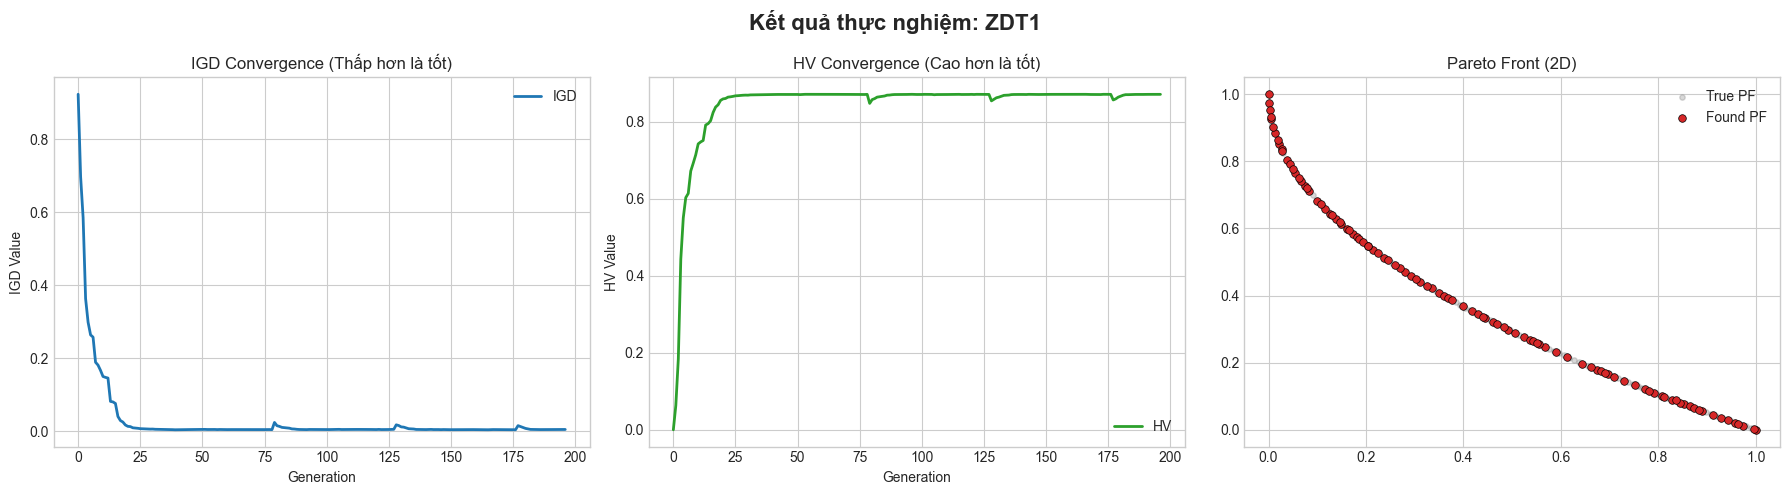

. DONE

→ Đang chạy ZDT2 (10 runs)... .........BẮT ĐẦU CHẠY (Lần cuối để vẽ hình): ZDT2
• Cấu hình: Obj=2 | Var=30 | Pop=100 | Gen=200
Thời gian chạy: 1.5625 giây
  >> IGD Final: 0.004597
  >> HV  Final: 0.537858


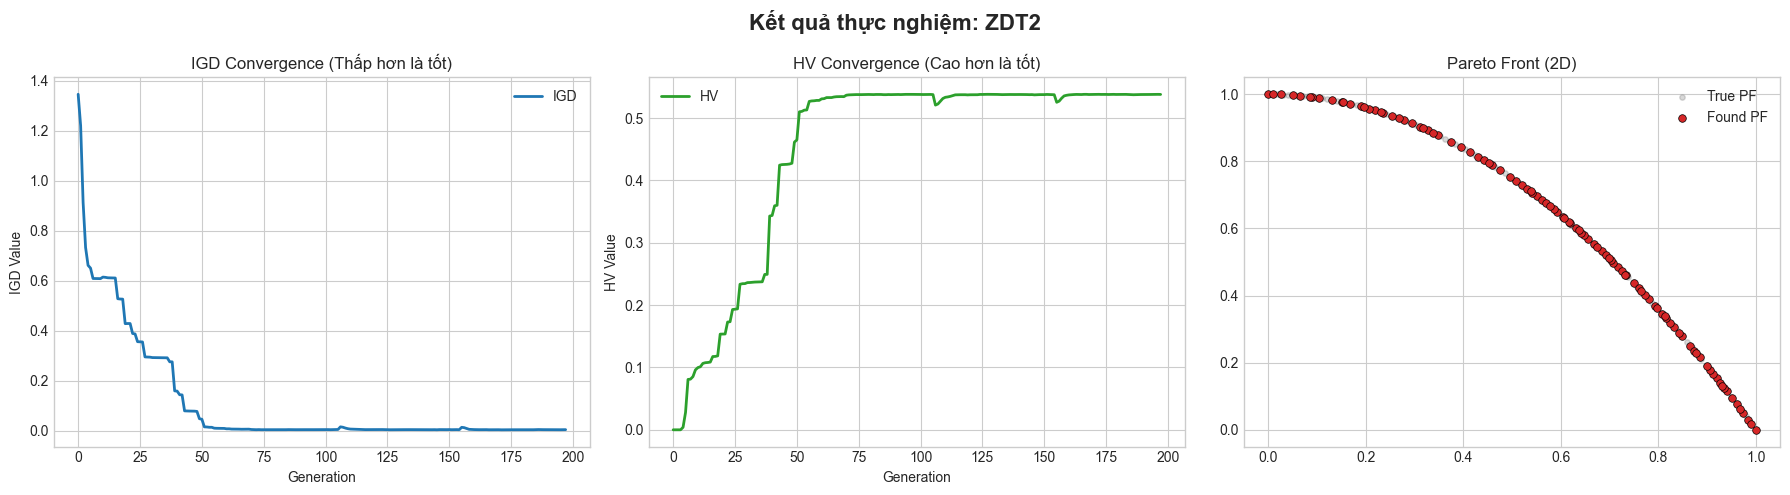

. DONE

→ Đang chạy ZDT3 (10 runs)... .........BẮT ĐẦU CHẠY (Lần cuối để vẽ hình): ZDT3
• Cấu hình: Obj=2 | Var=30 | Pop=100 | Gen=200
Thời gian chạy: 1.5724 giây
  >> IGD Final: 0.004903
  >> HV  Final: 1.023429


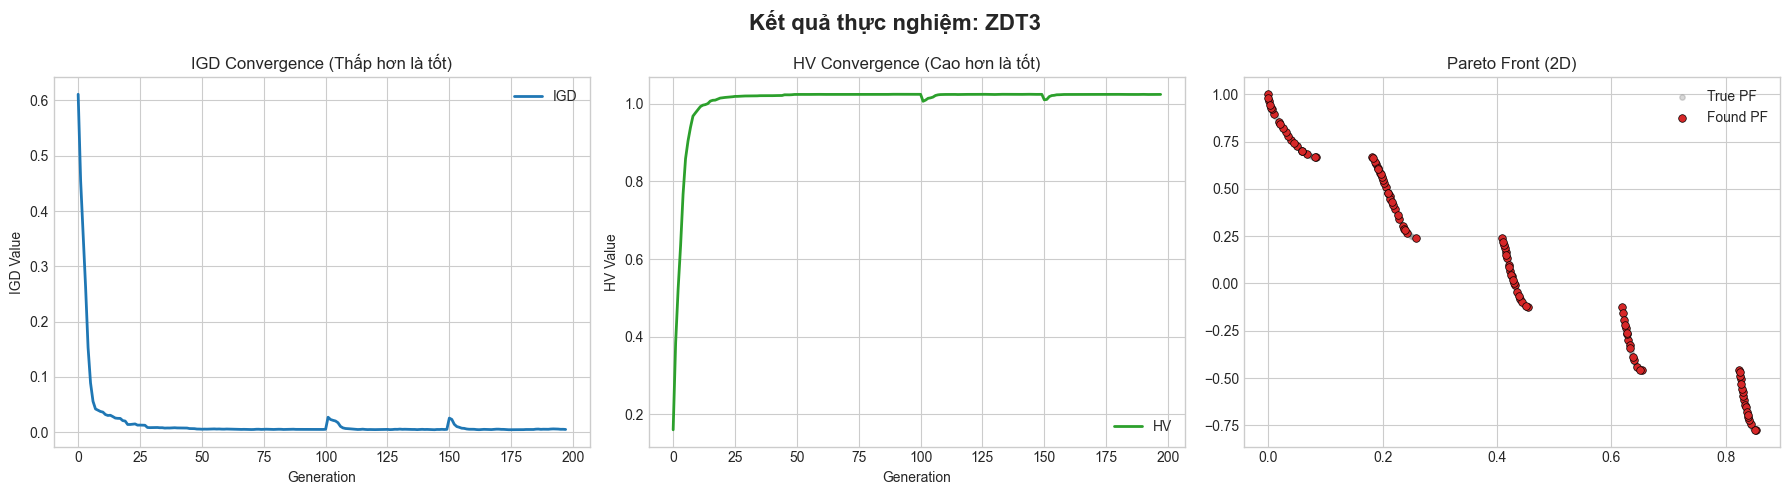

. DONE

→ Đang chạy ZDT4 (10 runs)... .........BẮT ĐẦU CHẠY (Lần cuối để vẽ hình): ZDT4
• Cấu hình: Obj=2 | Var=10 | Pop=100 | Gen=200
Thời gian chạy: 1.8157 giây
  >> IGD Final: 0.007956
  >> HV  Final: 0.862316


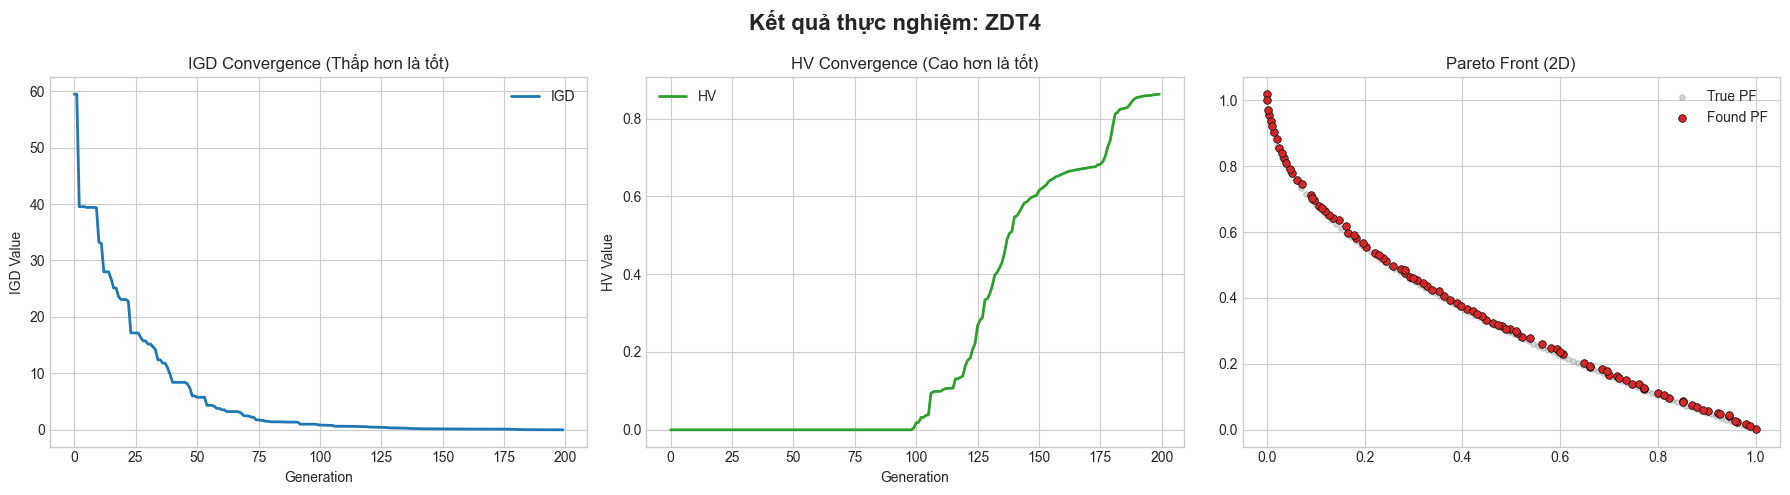

. DONE

→ Đang chạy ZDT6 (10 runs)... .........BẮT ĐẦU CHẠY (Lần cuối để vẽ hình): ZDT6
• Cấu hình: Obj=2 | Var=10 | Pop=100 | Gen=200
Thời gian chạy: 1.6365 giây
  >> IGD Final: 0.003911
  >> HV  Final: 0.431784


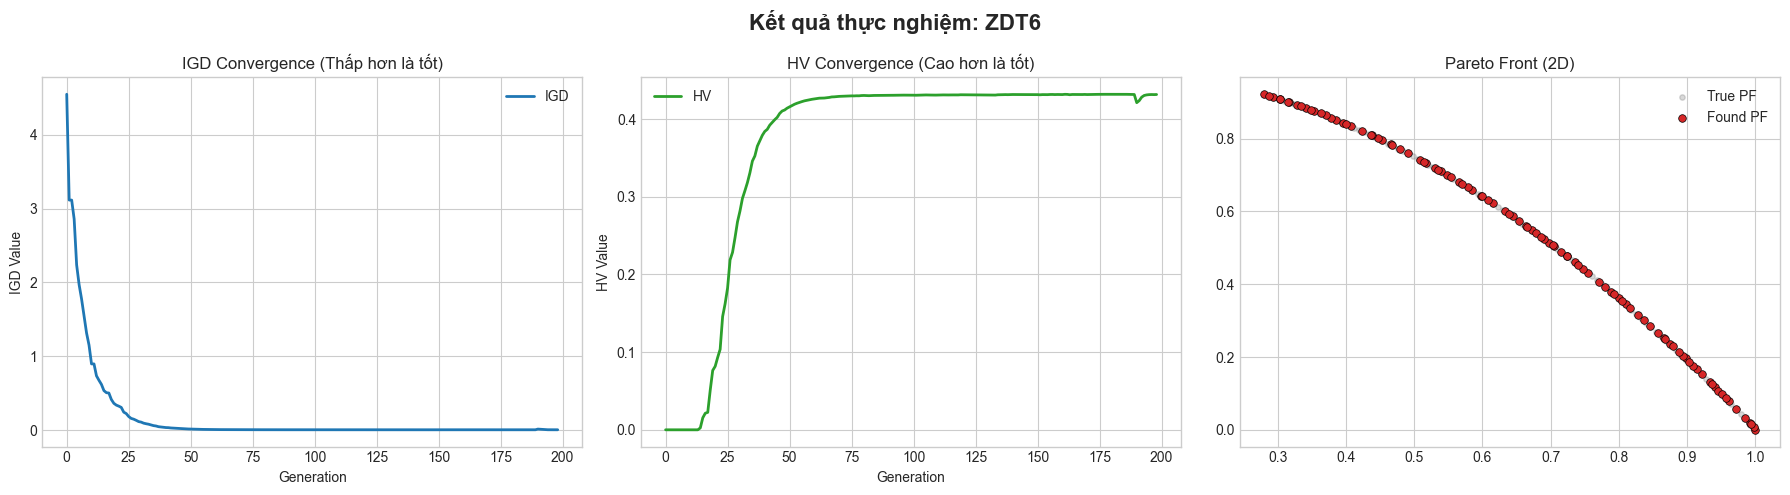

. DONE

                    KẾT QUẢ TỔNG HỢP (TRUNG BÌNH ± STD - 10 LẦN CHẠY)                     
╒═══════════╤══════════════════╤═════════╤═════════╤════════════════════╤════════════════════╤════════════╕
│ Problem   │ Algorithm        │   n_Var │   n_Obj │ IGD (Mean ± Std)   │ HV (Mean ± Std)    │   Time (s) │
╞═══════════╪══════════════════╪═════════╪═════════╪════════════════════╪════════════════════╪════════════╡
│ ZDT1      │ Improved NSGA-II │      30 │       2 │ 0.00470 (±0.00029) │ 0.87079 (±0.00032) │    1.54761 │
├───────────┼──────────────────┼─────────┼─────────┼────────────────────┼────────────────────┼────────────┤
│ ZDT2      │ Improved NSGA-II │      30 │       2 │ 0.00485 (±0.00047) │ 0.53739 (±0.00064) │    1.5358  │
├───────────┼──────────────────┼─────────┼─────────┼────────────────────┼────────────────────┼────────────┤
│ ZDT3      │ Improved NSGA-II │      30 │       2 │ 0.00616 (±0.00268) │ 1.02271 (±0.00212) │    1.5516  │
├───────────┼──────────────────┼─────

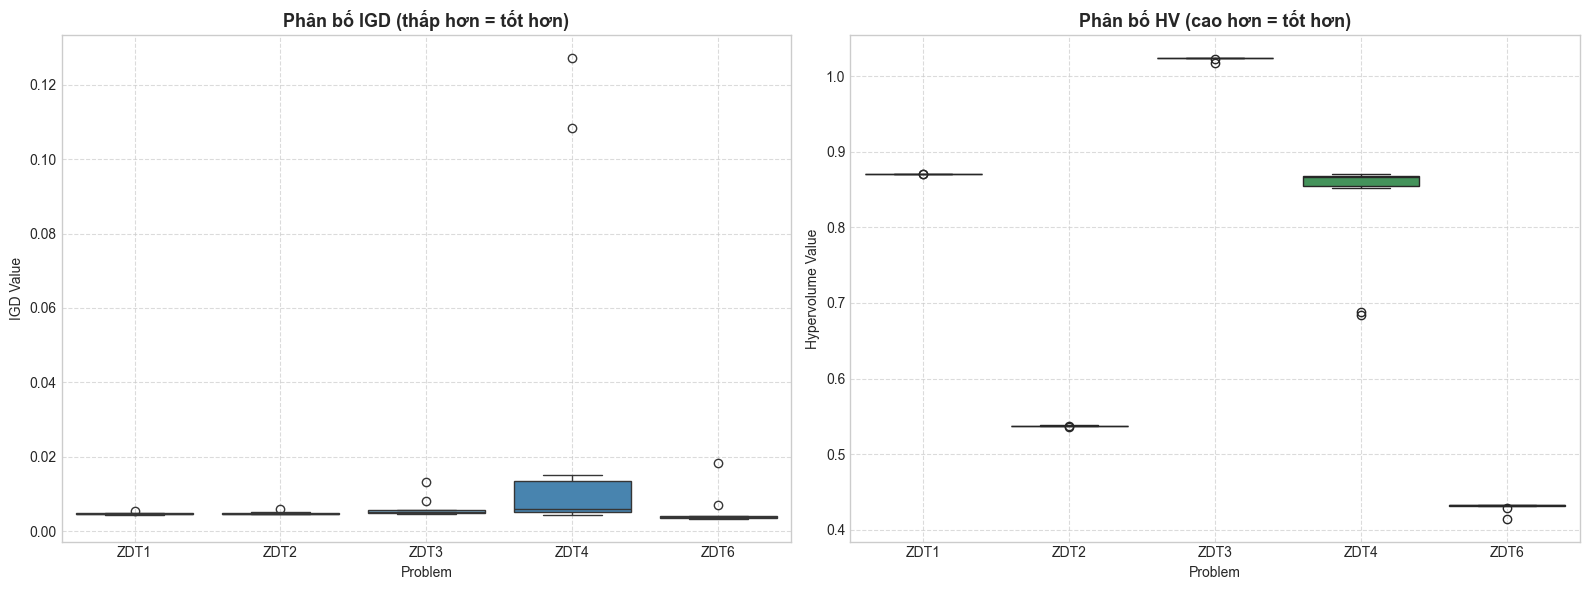


Đã lưu kết quả vào:
   • improved_nsga2_summary.csv
   • improved_nsga2_raw_data.csv


In [ ]:
# ====================== CONFIG ======================
POP_SIZE = 100
N_GEN = 200
N_RUNS = 10
SEED_BASE = 42

problems_list = ['zdt1', 'zdt2', 'zdt3', 'zdt4', 'zdt6']
# problems_list = ['dtlz1', 'dtlz2', 'dtlz3', 'dtlz4', 'dtlz5', 'dtlz6', 'dtlz7']

k_mapping_dtlz = {
    "dtlz1": 5, "dtlz2": 10, "dtlz3": 10, "dtlz4": 10,
    "dtlz5": 10, "dtlz6": 10, "dtlz7": 20
}

# ====================== RUN BENCHMARK (CLEAN) ======================
final_results_summary = []
all_raw_data = pd.DataFrame()

print("=== BẮT ĐẦU BENCHMARK Improved NSGA-II ===")

for p_name in problems_list:
    # Cấu hình bài toán
    if 'dtlz' in p_name.lower():
        n_obj = 3
        k = k_mapping_dtlz.get(p_name, 10)
        n_var = n_obj + k - 1
    else:  # ZDT
        n_obj = 2
        n_var = 30 if any(x in p_name for x in ['zdt1','zdt2','zdt3']) else 10

    temp_runs_data = []
    print(f"\n→ Đang chạy {p_name.upper()} ({N_RUNS} runs)... ", end="")

    for i in range(N_RUNS):
        current_seed = SEED_BASE + i
        np.random.seed(current_seed)
        random.seed(current_seed)

        is_last_run = (i == N_RUNS - 1)

        res = run_experiment(
            problem_name=p_name,
            n_gen=N_GEN,
            default_pop_size=POP_SIZE,
            seed=current_seed,
            n_var=n_var,
            n_obj=n_obj,
            do_plot=is_last_run
        )
        temp_runs_data.append(res)
        print(".", end="", flush=True)

    # Xử lý kết quả run
    df_temp = pd.DataFrame(temp_runs_data)
    mean_vals = df_temp.mean(numeric_only=True)
    std_vals = df_temp.std(numeric_only=True)

    summary_row = {
        'Problem': p_name.upper(),
        'Algorithm': "Improved NSGA-II",
        'n_Var': temp_runs_data[0]['n_Var'],
        'n_Obj': temp_runs_data[0]['n_Obj'],
        'IGD (Mean ± Std)': f"{mean_vals['IGD']:.5f} (±{std_vals['IGD']:.5f})",
        'HV (Mean ± Std)':  f"{mean_vals['HV']:.5f} (±{std_vals['HV']:.5f})",
        'Time (s)': mean_vals['Time (s)']
    }
    final_results_summary.append(summary_row)

    # Gom raw data
    all_raw_data = pd.concat([all_raw_data, df_temp], ignore_index=True)

    print(" DONE")

# ====================== SUMMARY & VISUALIZATION ======================
df_summary = pd.DataFrame(final_results_summary)

print("\n" + "="*90)
print(f"KẾT QUẢ TỔNG HỢP (TRUNG BÌNH ± STD - {N_RUNS} LẦN CHẠY)".center(90))
print("="*90)
print(tabulate(df_summary, headers='keys', tablefmt='fancy_grid', showindex=False))

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=all_raw_data, x='Problem', y='IGD', hue='Problem',
            legend=False, ax=axes[0], palette="Blues")
axes[0].set_title('Phân bố IGD (thấp hơn = tốt hơn)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('IGD Value')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.boxplot(data=all_raw_data, x='Problem', y='HV', hue='Problem',
            legend=False, ax=axes[1], palette="Greens")
axes[1].set_title('Phân bố HV (cao hơn = tốt hơn)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Hypervolume Value')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

df_summary.to_csv('improved_nsga2_summary.csv', index=False)
all_raw_data.to_csv('improved_nsga2_raw_data.csv', index=False)
print(f"\nĐã lưu kết quả vào:\n   • improved_nsga2_summary.csv\n   • improved_nsga2_raw_data.csv")